<a href="https://colab.research.google.com/github/brindha22001-wq/Brindha-D/blob/main/Copy_of_ML_Project_using_ANN_Brindha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

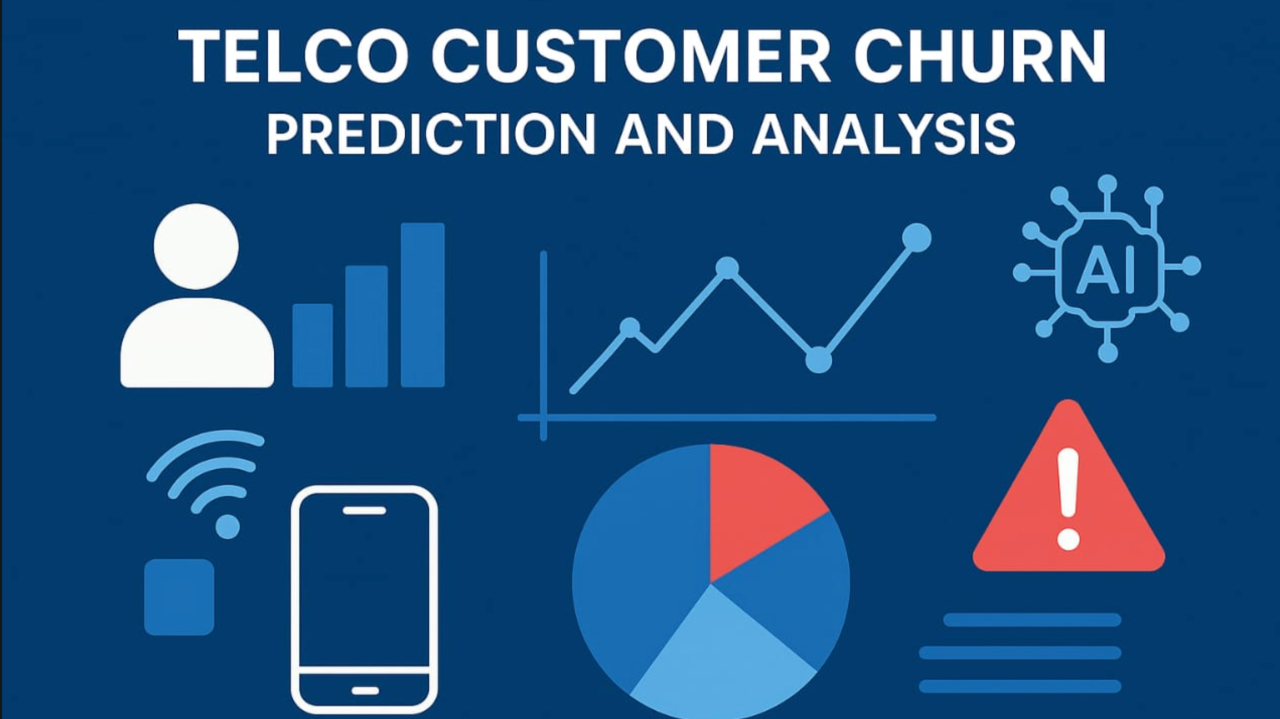

In [ ]:
#Liabraries:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocessing & Model Evaluation:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Keras:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.utils import to_categorical
from keras.datasets import mnist
from keras.callbacks import EarlyStopping

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [ ]:
import numpy as np
import pandas as pd

# give you file path here
churning = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn (1).csv')

churning

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
churning.shape

(7043, 21)

**Understanding the Dataset:**

***To gain insights into the dataset we first check for missing values and understand its structure. The dataset includes features such as:***

In [ ]:
churning.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
churning.columns = churning.columns.str.strip()
churning.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
print(churning.isnull().sum())
print(churning.describe())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


**tenure** – The number of months a customer has stayed with the company.

**InternetService** – The type of internet service the customer has DSL, Fiber optic or None.

**PaymentMethod** –
 The method the customer uses for payments.

**Churn** –
The target variable i.e Yes for customer churned and No for customer stayed.

In [ ]:
churning.drop_duplicates(inplace=True)

**Analyzing Churn Distribution**:

We check the number of churners and non-churners to understand the balance of the dataset.




Churn
No     5174
Yes    1869
Name: count, dtype: int64


/tmp/ipython-input-1863812799.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=churning, palette='rocket')


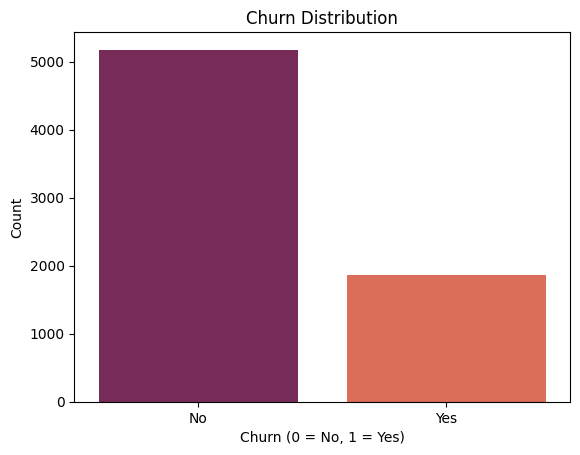

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print(churning['Churn'].value_counts())
sns.countplot(x='Churn', data=churning, palette='rocket')
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

**2. Data Preprocessing**

***Handling Missing and Incorrect Values***

Before processing we ensure that all numerical columns contain valid values. The TotalCharges column sometimes has empty spaces which need to be converted to numerical values.

**pd.to_numeric (dataset['TotalCharges'], errors='coerce')**

**converts the TotalCharges column to numerical format. If any value is not convertible (e.g., empty spaces), it replaces it with NaN.

**.fillna(dataset['TotalCharges'].median(), inplace=True)**

**replaces missing values (NaN) with the median of the column to maintain consistency in numerical values.




In [ ]:
churning['TotalCharges'] = pd.to_numeric(churning['TotalCharges'], errors='coerce')


In [ ]:
churning.fillna(churning['TotalCharges'].median(),inplace=True)

**Handling Categorical Variables**:

some features like State, International Plan and Voice Mail Plan are categorical and must be converted into numerical values for model training.

* LabelEncoder() converts categorical values into numerical form. Each unique category is assigned a numeric label.
* The loop iterates through each categorical column and applies fit_transform() to encode categorical variables into numbers.



In [ ]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
                    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
for col in categorical_cols:
    churning[col] = labelencoder.fit_transform(churning[col])

**Feature Selection and Splitting Data**:

*We separate the features (X) and target variable (y) and split the dataset into training and testing sets.*

*   X = dataset.drop(['customerID', 'Churn'], axis=1) removes the customerID (irrelevant for prediction) and Churn column (target variable).
*   y = dataset['Churn'] defines y as the target variable, which we want to predict.

*  train_test_split() splits data into 80% training and 20% testing for model evaluation.






In [ ]:
from sklearn.model_selection import train_test_split

X = churning.drop(['customerID', 'Churn'], axis=1)
y = churning['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Feature Scaling**:

Since features are on different scales we apply standardization to improve model performance. It prevents models from being biased toward larger numerical values and improves convergence speed in optimization algorithms like gradient descent.

*   StandardScaler(): Standardizes data by transforming it to have a mean of 0 and a standard deviation of 1 ensuring all features are on a similar scale.

*  fit_transform(X_train): Fits the scaler to the training data and transforms it.

*  transform(X_test): Transforms the test data using the same scaling parameters.




In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**3. Model Training and Prediction**:

For training our model we use Random Forest Classifier. It is an ensemble learning method that combines the results of multiple decision trees to make a final prediction.




In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
clf

RandomForestClassifier()

**4. Model Evaluation**:

Accuracy Score:

To measure model performance we calculate accuracy using the accuracy_score function.

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.80


**Confusion Matrix and Performance Metrics**:

**We evaluate precision, recall and accuracy using a confusion matrix.

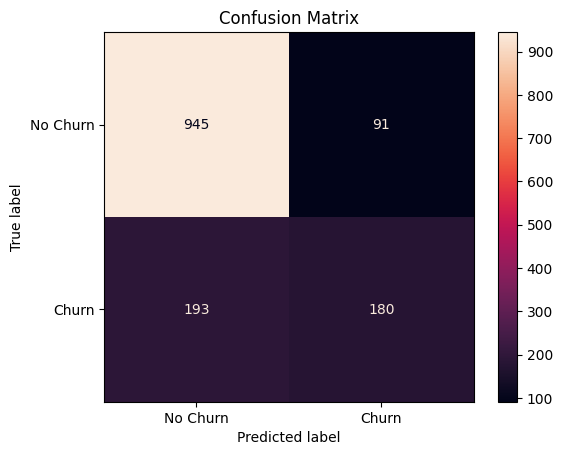

array([[945,  91],
       [193, 180]])

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="rocket")
plt.title('Confusion Matrix')
plt.show()
confusion_matrix(y_test, y_pred)

Confusion matrix shows how well the model predicts customer churn. It correctly identifies 945 non-churners and 180 churners. However 91 non-churners are wrongly classified as churners and 193 churners are missed. The high number of missed churners suggests the model may need further tuning.

In [ ]:
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409



**5. Building an Artificial Neural Network (ANN) Model**

Artificial Neural Networks (ANNs), also known as neural networks, are a set of algorithms, modeled loosely after the human brain, that are designed to recognize patterns. They are particularly good at tasks such as image recognition, natural language processing, and in our case, classification.

We will use Keras, a high-level API built on top of TensorFlow, to construct our ANN model. The process involves defining the model architecture, compiling it, and then training it with our preprocessed data.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

# Initialize the ANN model
ann_model = Sequential()

# Add the input layer and the first hidden layer
# The number of input features is the number of columns in X_train
ann_model.add(Dense(units=32, activation='relu', input_dim=X_train.shape[1]))
ann_model.add(Dropout(0.3)) # Adding dropout for regularization

# Add a second hidden layer
ann_model.add(Dense(units=16, activation='relu'))
ann_model.add(Dropout(0.3)) # Adding dropout for regularization

# Add the output layer
# For binary classification, use 1 unit and 'sigmoid' activation
ann_model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
# Optimizer: 'adam' is a good general-purpose optimizer
# Loss function: 'binary_crossentropy' for binary classification
# Metrics: 'accuracy' to monitor training progress
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

**6. Training the ANN Model**

Now we will train our ANN model using the `X_train` and `y_train` datasets. We'll specify the number of epochs (how many times the model sees the entire dataset) and the batch size (number of samples per gradient update).

In [ ]:
from keras.callbacks import EarlyStopping

# Define Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = ann_model.fit(X_train, y_train,
                        epochs=50,
                        batch_size=32,
                        validation_split=0.2, # Use a portion of training data for validation
                        callbacks=[early_stopping], # Add early stopping callback
                        verbose=1)


Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4695 - loss: 0.8560 - val_accuracy: 0.7684 - val_loss: 0.4588
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7461 - loss: 0.5117 - val_accuracy: 0.7888 - val_loss: 0.4258
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7571 - loss: 0.4885 - val_accuracy: 0.7941 - val_loss: 0.4211
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7738 - loss: 0.4733 - val_accuracy: 0.7950 - val_loss: 0.4176
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7643 - loss: 0.4646 - val_accuracy: 0.7924 - val_loss: 0.4161
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7729 - loss: 0.4596 - val_accuracy: 0.7968 - val_loss: 0.4152
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7736 - loss: 0.4683 - val_accuracy: 0.8004 - val_loss: 0.4140
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7871 - loss: 0.4544 - val_accuracy: 0.

**7. Evaluating the ANN Model**

After training, we'll evaluate the performance of our ANN model on the test set using various metrics like accuracy, classification report, and a confusion matrix.

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
ANN Model Accuracy: 0.82


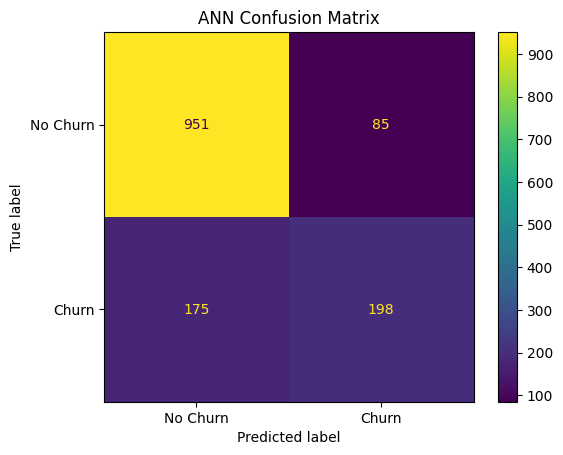


ANN Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.70      0.53      0.60       373

    accuracy                           0.82      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.81      0.82      0.81      1409



In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Predict probabilities on the test set
y_pred_ann_proba = ann_model.predict(X_test)

# Convert probabilities to binary predictions (0 or 1)
y_pred_ann = (y_pred_ann_proba > 0.5).astype(int)

# Evaluate accuracy
accuracy_ann = accuracy_score(y_test, y_pred_ann)
print(f"ANN Model Accuracy: {accuracy_ann:.2f}")

# Generate and plot confusion matrix
cm_ann = confusion_matrix(y_test, y_pred_ann)
disp_ann = ConfusionMatrixDisplay(confusion_matrix=cm_ann, display_labels=["No Churn", "Churn"])
disp_ann.plot(cmap="viridis")
plt.title('ANN Confusion Matrix')
plt.show()
confusion_matrix(y_test, y_pred_ann)

# Print classification report
print("\nANN Classification Report:")
print(classification_report(y_test, y_pred_ann))


In [ ]:
accuracy_ann

0.815471965933286

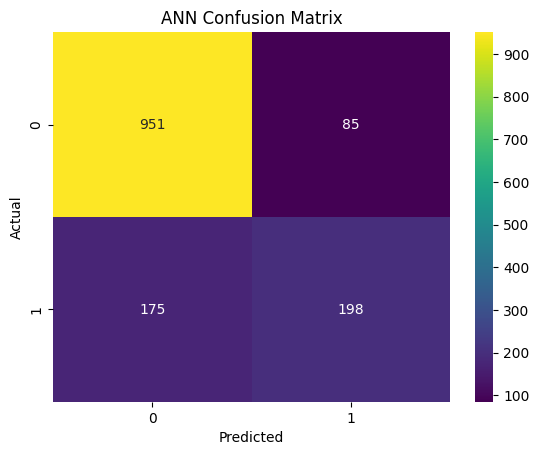

In [ ]:
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='viridis')
plt.title('ANN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()